<a href="https://colab.research.google.com/github/Syed-Hussain-Faraz/iHub_Sept26_Projects_and_Labs/blob/main/AIML_Module_1_Lab_3_Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation

Module 1, Lab 3

In this lab, we will see how augmentation of data samples help in improving the machine learning performance. Augmentation is the process of creating new data samples by making reasonable modifications to the original data samples. This is particularly useful when the size of the training data is small. We will use the MNISt dataset for this lab. We will also reuse functions from the previous labs.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

### Why Data Augmentation?

**Problem:** Machine learning models need lots of data to learn well. Collecting data is expensive and time-consuming.

**Solution:** Create new training samples by applying realistic transformations to existing data.

### Key Concepts

**Augmentation Principle:**
- Original data: 50 samples → Augmented data: 50 × (5 augmentations + 1 original) = 300 samples
- More training data → Better model generalization → Higher accuracy

**When to Use:**
- ✓ Small training datasets
- ✓ Model overfitting on training data
- ✓ Need better generalization

**Important Rule:** Augmentations must preserve the label!
- ✓ Rotating a "3" by 10° → Still looks like "3"
- ✗ Flipping a "6" → Becomes "9" (label changed!)

---

In [ ]:
# loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# normalizing the data
train_X = train_X / 255
test_X = test_X / 255

# subsample from images and labels. Otherwise it will take too long!
train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let us borrow a few functions from the previous labs:

In [ ]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

In this lab, we will use the image pixels themselves as features, instead of extracting features. Each image has 28*28 pixels, so we will flatten them to 784 pixels to use as features. Note that this is very compute intensive and will take a long time. Let us first check the baseline accuracy on the test set without any augmentations. We hope that adding augmentations will help us to get better results.

In [ ]:
testpred = NN(train_X, train_y, test_X)
print("Baseline accuracy without augmentation:",
      Accuracy(test_y, testpred)*100, "%")

Baseline accuracy without augmentation: 64.72 %


Let us try to improve this accuracy using augmentations. When we create augmentations, we have to make sure that the changes reflect what will naturally occur in the dataset. For example, we should not add colour to our samples as an augmentation because they do not naturally occur. We should not also flip the images in MNIST, because flipped images have different meanings for digits. So, we will use the following augmentations:

### Augmentation 1: Rotation

Let us try rotating the image a little. We will use the `rotate` function from the `skimage` module. We will rotate the image by 10 degrees and -10 degrees. Rotation is a reasonable augmentation because the digit will still be recognizable even after rotation and is representative of the dataset.

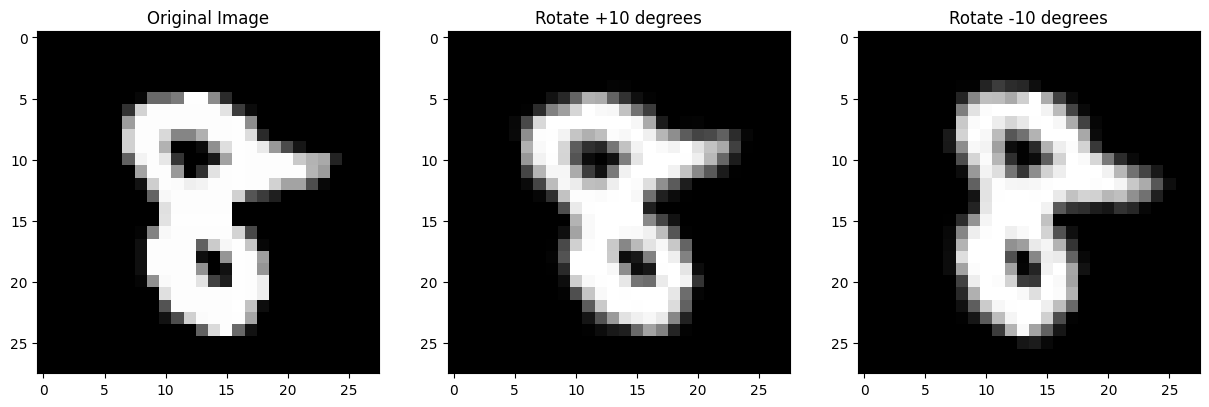

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(train_X[2], cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(rotate(train_X[2], 10), cmap="gray")
axs[1].set_title("Rotate +10 degrees")

axs[2].imshow(rotate(train_X[2], -10), cmap="gray")
axs[2].set_title("Rotate -10 degrees")

plt.show()

After rotating, the the class of the image is still the same. Let us make a function to rotate multiple images by random angles. We want a slightly different image every time we run this function. So, we generate a random number between 0 and 1 and change it so that it lies between -constraint/2 and +constraint/2

In [ ]:
def augRotate(sample, angleconstraint):
    """
    This function takes in a sample and an angle constraint and returns the augmented sample
    by rotating the sample by a random angle within the angle constraint

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    angleconstraint: the maximum angle by which the sample can be rotated

    returns: the augmented sample which is the input sample rotated by a random angle within the angle constraint
    """
    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        # make sure the sample is 3 dimensional
        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))  # generate random numbers for angles
    # make the random angle constrained
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()  # preallocate the augmented array to make it faster
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)  # take care if the input had only one sample.

This function returns a slightly different image each time we call it. So we can increase the number of images in the sample by any multiple.

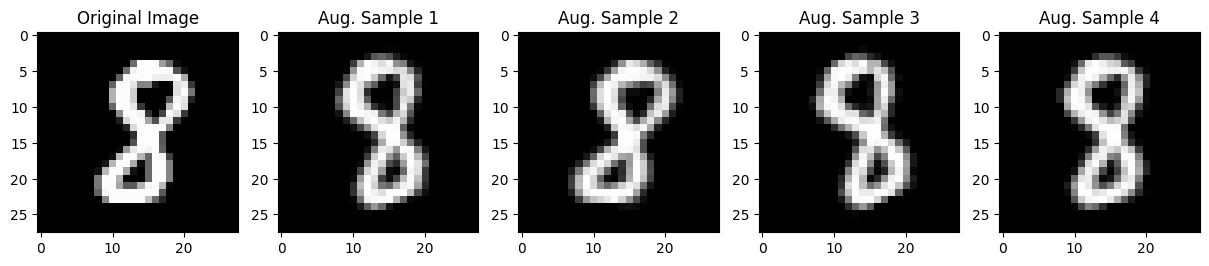

In [ ]:
sample = train_X[20]
angleconstraint = 70

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[1].set_title("Aug. Sample 1")

axs[2].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[2].set_title("Aug. Sample 2")

axs[3].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[3].set_title("Aug. Sample 3")

axs[4].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[4].set_title("Aug. Sample 4")

plt.show()

Let us augment the whole dataset and see if this improves the test accuracy

In [ ]:
# hyperparameters
angleconstraint = 60
naugmentations = 5

# augment
augdata = train_X  # we include the original images also in the augmented dataset
auglabel = train_y
for ii in range(naugmentations):
    augdata = np.concatenate(
        (augdata, augRotate(train_X, angleconstraint))
    )  # concatenate the augmented data to the set
    auglabel = np.concatenate(
        (auglabel, train_y)
    )  # the labels don't change when we augment

# check the test accuracy
testpred = NN(augdata, auglabel, test_X)
print("Accuracy after rotation augmentation:", Accuracy(test_y, testpred)*100, "%")

Accuracy after rotation augmentation: 67.66 %


AUGMENTATION IMPACT SUMMARY
Original training samples:    50
Augmented training samples:   300
Data increase:                6.0x

Baseline accuracy:            64.72%
After augmentation:           67.66%
Improvement:                  +2.94%


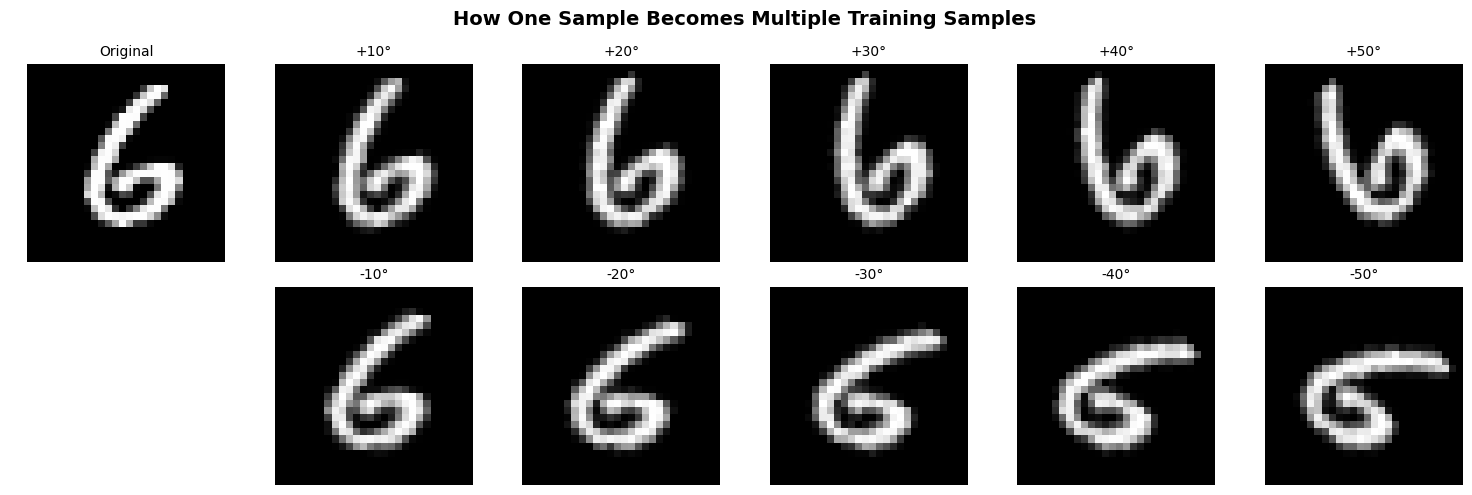

In [ ]:
print("=" * 60)
print("AUGMENTATION IMPACT SUMMARY")
print("=" * 60)

original_size = len(train_X)
augmented_size = len(augdata)
baseline_acc = 64.72
augmented_acc = 67.66

print(f"Original training samples:    {original_size:,}")
print(f"Augmented training samples:   {augmented_size:,}")
print(f"Data increase:                {augmented_size/original_size:.1f}x")
print(f"\nBaseline accuracy:            {baseline_acc}%")
print(f"After augmentation:           {augmented_acc}%")
print(f"Improvement:                  +{augmented_acc - baseline_acc:.2f}%")
print("=" * 60)

# Visualize: Show how one digit gets augmented
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
sample_digit = train_X[5]  # Pick one sample

axes[0, 0].imshow(sample_digit, cmap='gray')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# Generate 11 augmented versions
angles = [10, 20, 30, 40, 50]
for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, angle)
    axes[0, i+1].imshow(aug_sample, cmap='gray')
    axes[0, i+1].set_title(f'+{angle}°', fontsize=10)
    axes[0, i+1].axis('off')

for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, -angle)
    axes[1, i+1].imshow(aug_sample, cmap='gray')
    axes[1, i+1].set_title(f'-{angle}°', fontsize=10)
    axes[1, i+1].axis('off')

axes[1, 0].axis('off')
plt.suptitle('How One Sample Becomes Multiple Training Samples',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

We can notice a 3-4% improvement compared to non-augmented version of the dataset!

The angle constraint is a hyperparameter which we have to tune using a validation set. (Here we are not doing that for time constraints). Let us try a grid search to find the best angle constraint. We will try angles between 0 and 90 degrees. We can also try different multiples of the original dataset. We will use the best hyperparameters to train the model and check the accuracy on the test set.

In [ ]:
angleconstraints = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]  # the values we want to test
accuracies = np.zeros(
    len(angleconstraints), dtype=float
)  # we will save the values here

for ii in range(len(angleconstraints)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotate(train_X, angleconstraints[ii]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after rotation augmentation constrained by",
        angleconstraints[ii],
        "degrees is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after rotation augmentation constrained by 0 degrees is 64.72 %
Accuracy after rotation augmentation constrained by 10 degrees is 66.79 %
Accuracy after rotation augmentation constrained by 20 degrees is 67.84 %
Accuracy after rotation augmentation constrained by 30 degrees is 68.47 %
Accuracy after rotation augmentation constrained by 40 degrees is 67.63 %
Accuracy after rotation augmentation constrained by 50 degrees is 67.65 %
Accuracy after rotation augmentation constrained by 60 degrees is 65.3 %
Accuracy after rotation augmentation constrained by 70 degrees is 66.06 %
Accuracy after rotation augmentation constrained by 80 degrees is 64.61 %
Accuracy after rotation augmentation constrained by 90 degrees is 64.31 %


Let us see the best value for angle constraint: (Ideally this should be done on validation set, not test set)

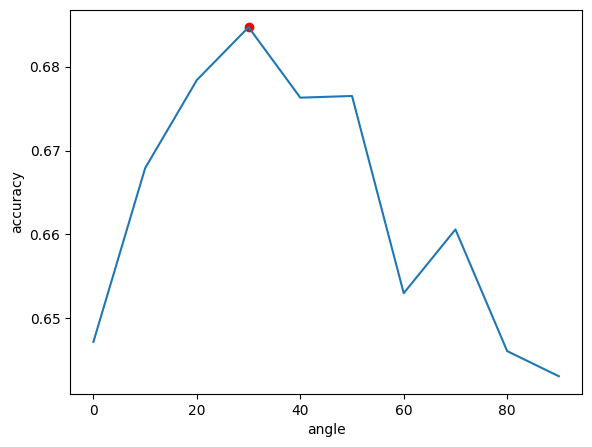

In [ ]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# plot the variation of accuracy
ax.plot(angleconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")

# plot the maximum accuracy
maxind = np.argmax(accuracies)
plt.scatter(angleconstraints[maxind], accuracies[maxind], c="red")

### Augmentation 2: Shear


Let us try one more augmentation: shear. Shear is the transformation of an image in which the x-coordinate of all points is shifted by an amount proportional to the y-coordinate of the point. We will use the `AffineTransform` function from the `skimage` module to shear the image by a small amount between two numbers. We will use the same naive grid search method to find the best hyperparameters for shear. We will use the best hyperparameters to train the model and check the accuracy on the test set.

In [ ]:
def shear(sample, amount):
    """
    This function takes in a sample and an amount and returns the augmented sample
    by shearing the sample by the given amount

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    amount: the amount by which the sample should be sheared

    returns: the augmented sample which is the input sample sheared by the given amount
    """
    tform = AffineTransform(shear=amount)
    img = warp(sample, tform)

    # Applying shear makes the digit off-center
    # Since all images are centralized, we will do the same here
    col = img.sum(0).nonzero()[0]
    row = img.sum(1).nonzero()[0]
    if len(col) > 0 and len(row) > 0:
        xshift = int(sample.shape[0] / 2 - (row[0] + row[-1]) / 2)
        yshift = int(sample.shape[1] / 2 - (col[0] + col[-1]) / 2)
        img = np.roll(img, (xshift, yshift), (0, 1))
    return img

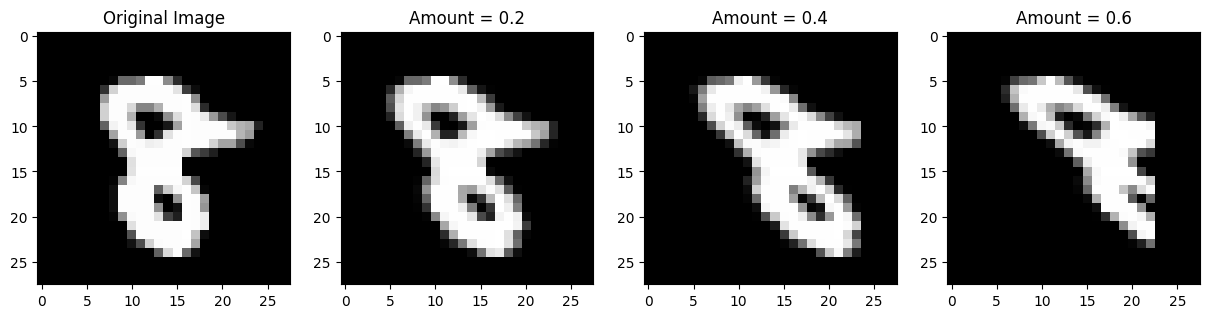

In [ ]:
sample = train_X[2]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(shear(sample, 0.2), cmap="gray")
axs[1].set_title("Amount = 0.2")

axs[2].imshow(shear(sample, 0.4), cmap="gray")
axs[2].set_title("Amount = 0.4")

axs[3].imshow(shear(sample, 0.6), cmap="gray")
axs[3].set_title("Amount = 0.6")

plt.show()

Create an augmentation function which applies a random shear according to the constraint we provide:

In [ ]:
def augShear(sample, shearconstraint):
    """
    This function takes in a sample and a shear constraint and returns the augmented sample
    by shearing the sample by a random amount within the shear constraint

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    shearconstraint: the maximum shear by which the sample can be sheared

    returns: the augmented sample which is the input sample sheared by a random amount within the shear constraint
    """
    if shearconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        # make sure the sample is 3 dimensional
        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))  # generate random numbers for shear
    amt = (amt - 0.5) * shearconstraint  # make the random shear constrained
    nsample = sample.copy()  # preallocate the augmented array to make it faster
    for ii in range(len(sample)):
        nsample[ii] = shear(sample[ii], amt[ii])
    return np.squeeze(nsample)  # take care if the input had only one sample.

Let us do a grid search to find the best shear constraint.

In [ ]:
shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
    1.8,
    2.0,
]  # the values we want to test
accuracies = np.zeros(
    len(shearconstraints), dtype=float
)  # we will save the values here

for ii in range(len(shearconstraints)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augShear(train_X, shearconstraints[ii]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after shear augmentation constrained by",
        shearconstraints[ii],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after shear augmentation constrained by 0 is 64.72 %
Accuracy after shear augmentation constrained by 0.2 is 62.79 %
Accuracy after shear augmentation constrained by 0.4 is 64.41 %
Accuracy after shear augmentation constrained by 0.6 is 65.71000000000001 %
Accuracy after shear augmentation constrained by 0.8 is 65.78 %
Accuracy after shear augmentation constrained by 1.0 is 65.42999999999999 %
Accuracy after shear augmentation constrained by 1.2 is 63.6 %
Accuracy after shear augmentation constrained by 1.4 is 63.65 %
Accuracy after shear augmentation constrained by 1.6 is 61.809999999999995 %
Accuracy after shear augmentation constrained by 1.8 is 63.029999999999994 %
Accuracy after shear augmentation constrained by 2.0 is 64.14 %


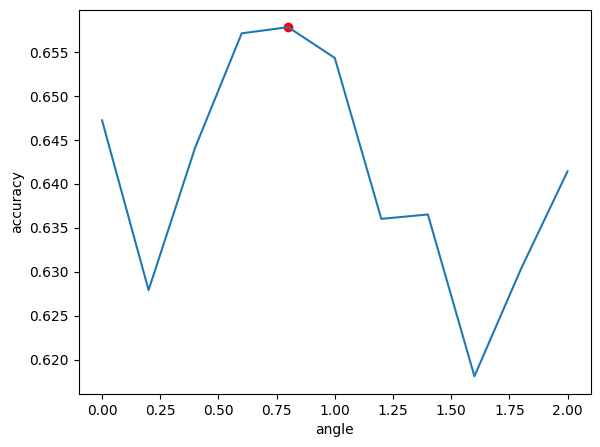

In [ ]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# plot the variation of accuracy
ax.plot(shearconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")

# plot the maximum accuracy
maxind = np.argmax(accuracies)
plt.scatter(shearconstraints[maxind], accuracies[maxind], c="red")

### Augmentation 3: Rotation + Shear



We can do multiple augmentations at the same time. Here is a function to do both shear and rotation to the sample. In this case, we will have two hyperparameters.

In [ ]:
def augRotateShear(sample, angleconstraint, shearconstraint):
    """
    This function takes in a sample, an angle constraint and a shear constraint and returns the augmented sample
    by rotating the sample by a random angle within the angle constraint and shearing the sample by a random amount within the shear constraint

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    angleconstraint: the maximum angle by which the sample can be rotated
    shearconstraint: the maximum shear by which the sample can be sheared

    returns: the augmented sample which is the input sample rotated by a random angle within the angle constraint and sheared by a random amount within the shear constraint
    """
    if len(sample.shape) == 2:
        # make sure the sample is 3 dimensional
        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))  # generate random numbers for shear
    amt = (amt - 0.5) * shearconstraint  # make the random shear constrained
    angle = rng.random(len(sample))  # generate random numbers for angles
    # make the random angle constrained
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()  # preallocate the augmented array to make it faster
    for ii in range(len(sample)):
        nsample[ii] = rotate(
            shear(sample[ii], amt[ii]), angle[ii]
        )  # first apply shear, then rotate
    return np.squeeze(nsample)  # take care if the input had only one sample.

Since we have two hyperparameters, we have to do the grid search on a 2 dimensional matrix. We can use our previous experience to inform where to search for the best hyperparameters.

In [18]:
shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
]  # the values we want to test
angleconstraints = [0, 10, 20, 30, 40, 50, 60]  # the values we want to test
# cartesian product of both
hyp = cartesian((shearconstraints, angleconstraints))

accuracies = np.zeros(len(hyp), dtype=float)  # we will save the values here

for ii in range(len(hyp)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotateShear(train_X, hyp[ii][0], hyp[ii][1]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after augmentation shear:",
        hyp[ii][0],
        "angle:",
        hyp[ii][1],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after augmentation shear: 0.0 angle: 0.0 is 63.32 %
Accuracy after augmentation shear: 0.0 angle: 10.0 is 63.959999999999994 %
Accuracy after augmentation shear: 0.0 angle: 20.0 is 60.64000000000001 %
Accuracy after augmentation shear: 0.0 angle: 30.0 is 63.019999999999996 %
Accuracy after augmentation shear: 0.0 angle: 40.0 is 64.14999999999999 %
Accuracy after augmentation shear: 0.0 angle: 50.0 is 61.72 %
Accuracy after augmentation shear: 0.0 angle: 60.0 is 63.7 %
Accuracy after augmentation shear: 0.2 angle: 0.0 is 63.41 %
Accuracy after augmentation shear: 0.2 angle: 10.0 is 61.25000000000001 %
Accuracy after augmentation shear: 0.2 angle: 20.0 is 60.6 %
Accuracy after augmentation shear: 0.2 angle: 30.0 is 60.07 %
Accuracy after augmentation shear: 0.2 angle: 40.0 is 63.690000000000005 %
Accuracy after augmentation shear: 0.2 angle: 50.0 is 60.12 %
Accuracy after augmentation shear: 0.2 angle: 60.0 is 63.72 %
Accuracy after augmentation shear: 0.4 angle: 0.0 is 63.37000

Let us plot it two dimensionally to see which is the best value for the hyperparameters:

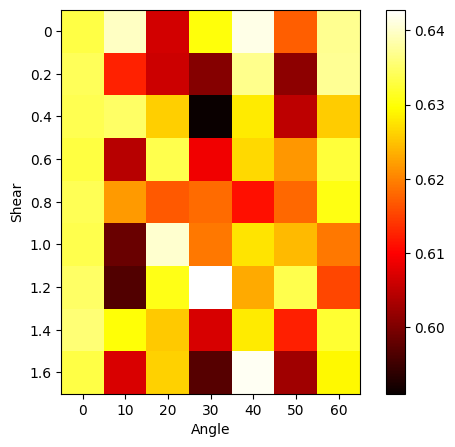

In [19]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
im = ax.imshow(
    accuracies.reshape((len(shearconstraints), len(angleconstraints))), cmap="hot"
)
ax.set_xlabel("Angle")
ax.set_ylabel("Shear")
ax.set_xticks(np.arange(len(angleconstraints)))
ax.set_xticklabels(angleconstraints)
ax.set_yticks(np.arange(len(shearconstraints)))
ax.set_yticklabels(shearconstraints)
plt.colorbar(im)

It seems that rotation and shear don't mix! The best accuracy is when rotation is zero.

## Questions
Try these questions for better understanding. You may not be able to solve all of them.
1. What is the best value for angle constraint and shear constraint you got? How much did the accuracy improve as compared to not using augmentations?
2. Can you increase the accuracy by increasing the number of augmentations from each sample?
3. Try implementing a few augmentations of your own and experimenting with them. A good reference is <a href=https://www.analyticsvidhya.com/blog/2019/12/image-augmentation-deep-learning-pytorch/>here. </a>
4. Try combining various augmentations. What is the highest accuracy you can get? What is the smallest training dataset you can take and still get accuracy above 50%?

Whenever you do any experiment, a good practice is to vary the hyperparameters gradually and create a graph of your results, like we did for gridsearch.

> Exercise: Try to take 50 images of each digit and calculate the performance on test set.

##Answers

Answer 1.  
The baseline accuracy without augmentation was 64.72%. For rotation augmentation, the best angle constraint was 30°, which achieved 68.47% accuracy. This represents an improvement of 3.75 percentage points over the baseline.

For shear augmentation, the best shear constraint was 0.8, which achieved 65.78%, an improvement of 1.06 percentage points.

When rotation and shear were combined, the best observed accuracy was 64.28% at a shear constraint of 1.2 and angle constraint of 30°. Therefore, combining the two transformations did not improve the result in this experiment.

Answer 2.

In [21]:
# Q2: Effect of number of augmentations on accuracy

naugmentations_list = [0, 1, 2, 3, 5, 7, 10]
accuracies_naug = []

# Use the best rotation constraint found earlier
angleconstraint = 30

for naug in naugmentations_list:

    # Start with original training data
    augdata = train_X
    auglabel = train_y

    # Add naug rotated versions
    for jj in range(naug):

        augdata = np.concatenate(
            (
                augdata,
                augRotate(train_X, angleconstraint)
            )
        )

        auglabel = np.concatenate(
            (
                auglabel,
                train_y
            )
        )

    # Test the classifier
    testpred = NN(
        augdata,
        auglabel,
        test_X
    )

    acc = Accuracy(
        test_y,
        testpred
    )

    accuracies_naug.append(acc)

    print(
        "Number of augmentations:",
        naug,
        "| Training samples:",
        len(augdata),
        "| Accuracy:",
        acc * 100,
        "%"
    )

Number of augmentations: 0 | Training samples: 50 | Accuracy: 64.72 %
Number of augmentations: 1 | Training samples: 100 | Accuracy: 65.35 %
Number of augmentations: 2 | Training samples: 150 | Accuracy: 67.12 %
Number of augmentations: 3 | Training samples: 200 | Accuracy: 66.35 %
Number of augmentations: 5 | Training samples: 300 | Accuracy: 68.27 %
Number of augmentations: 7 | Training samples: 400 | Accuracy: 68.84 %
Number of augmentations: 10 | Training samples: 550 | Accuracy: 68.72 %


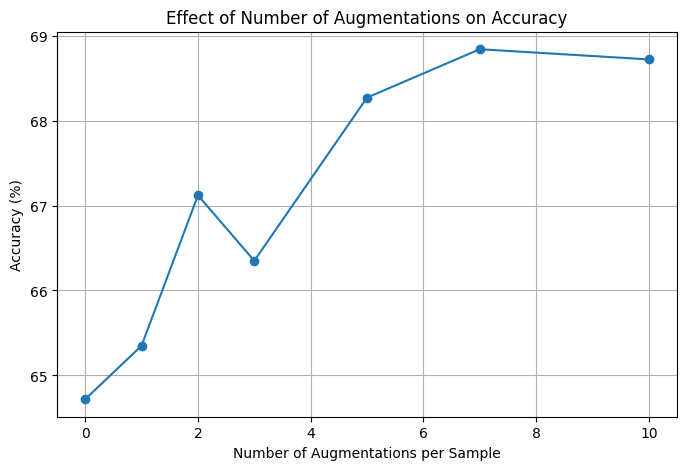

In [22]:
# Plot accuracy vs number of augmentations

plt.figure(figsize=(8, 5))

plt.plot(
    naugmentations_list,
    np.array(accuracies_naug) * 100,
    marker="o"
)

plt.xlabel("Number of Augmentations per Sample")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Number of Augmentations on Accuracy")

plt.grid()
plt.show()

In [23]:
best_index = np.argmax(accuracies_naug)

print(
    "Best number of augmentations:",
    naugmentations_list[best_index]
)

print(
    "Best accuracy:",
    accuracies_naug[best_index] * 100,
    "%"
)

print(
    "Baseline accuracy:",
    accuracies_naug[0] * 100,
    "%"
)

print(
    "Improvement:",
    (accuracies_naug[best_index] - accuracies_naug[0]) * 100,
    "percentage points"
)

Best number of augmentations: 7
Best accuracy: 68.84 %
Baseline accuracy: 64.72 %
Improvement: 4.120000000000001 percentage points


Effect of the number of augmentations on classifier accuracy:

The number of augmentations was varied from 0 to 10 using a rotation constraint of 30°. The results were:

No of augmentations : Accuracy  
0	: 64.72%   
1	: 65.35%  
2	: 67.12%  
3	: 66.35%  
5	: 68.27%  
7	: 68.84%  
10 : 68.72%  

The best accuracy of 68.84% was obtained with 7 augmentations per original sample. The baseline accuracy without augmentation was 64.72%, giving an improvement of 4.12 percentage points.

The accuracy does not increase continuously with the number of augmentations. It improves overall up to 7 augmentations, but slightly decreases at 10 augmentations. This shows that adding more augmented samples can improve classifier performance, but beyond an appropriate point, additional augmentations may provide little or no benefit.

Conclusion: For this experiment, 7 augmentations per sample gave the highest observed accuracy of 68.84%.

Answer 3.

In [25]:
def translate_image(image, max_shift):
    """
    Randomly translate an image horizontally and vertically.
    max_shift: maximum number of pixels to shift.
    """

    shift_x = np.random.randint(-max_shift, max_shift + 1)
    shift_y = np.random.randint(-max_shift, max_shift + 1)

    translated = np.roll(image, shift_x, axis=1)
    translated = np.roll(translated, shift_y, axis=0)

    # Remove wrapped pixels
    if shift_x > 0:
        translated[:, :shift_x] = 0
    elif shift_x < 0:
        translated[:, shift_x:] = 0

    if shift_y > 0:
        translated[:shift_y, :] = 0
    elif shift_y < 0:
        translated[shift_y:, :] = 0

    return translated

In [26]:
def augTranslate(samples, max_shift):

    augmented_samples = []

    for sample in samples:
        augmented_samples.append(
            translate_image(sample, max_shift)
        )

    return np.array(augmented_samples)

In [27]:
translation_constraints = [0, 1, 2, 3, 4, 5]

accuracies_translation = []

for max_shift in translation_constraints:

    if max_shift == 0:
        augdata = train_X
        auglabel = train_y

    else:
        augdata = np.concatenate(
            (
                train_X,
                augTranslate(train_X, max_shift)
            )
        )

        auglabel = np.concatenate(
            (
                train_y,
                train_y
            )
        )

    testpred = NN(
        augdata,
        auglabel,
        test_X
    )

    acc = Accuracy(
        test_y,
        testpred
    )

    accuracies_translation.append(acc)

    print(
        "Translation:",
        max_shift,
        "pixels | Training samples:",
        len(augdata),
        "| Accuracy:",
        acc * 100,
        "%"
    )

Translation: 0 pixels | Training samples: 50 | Accuracy: 64.72 %
Translation: 1 pixels | Training samples: 100 | Accuracy: 64.98 %
Translation: 2 pixels | Training samples: 100 | Accuracy: 63.56 %
Translation: 3 pixels | Training samples: 100 | Accuracy: 62.53999999999999 %
Translation: 4 pixels | Training samples: 100 | Accuracy: 64.25999999999999 %
Translation: 5 pixels | Training samples: 100 | Accuracy: 61.45 %


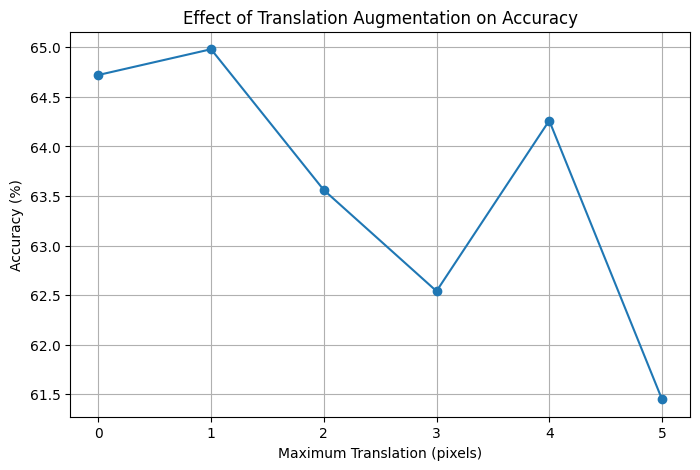

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    translation_constraints,
    np.array(accuracies_translation) * 100,
    marker="o"
)

plt.xlabel("Maximum Translation (pixels)")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Translation Augmentation on Accuracy")

plt.grid()
plt.show()

In [29]:
best_index = np.argmax(accuracies_translation)

print(
    "Best translation:",
    translation_constraints[best_index],
    "pixels"
)

print(
    "Best accuracy:",
    accuracies_translation[best_index] * 100,
    "%"
)

print(
    "Baseline accuracy:",
    accuracies_translation[0] * 100,
    "%"
)

print(
    "Improvement:",
    (accuracies_translation[best_index]
     - accuracies_translation[0]) * 100,
    "percentage points"
)

Best translation: 1 pixels
Best accuracy: 64.98 %
Baseline accuracy: 64.72 %
Improvement: 0.26000000000000467 percentage points


Translation augmentation was tested by shifting the MNIST images horizontally and vertically by different maximum pixel values.

Maximum translation : Accuracy  
0 pixels : 64.72%  
1 pixel : 64.98%  
2 pixels : 63.56%  
3 pixels : 62.54%  
4 pixels : 64.26%  
5 pixels : 61.45%  

The best accuracy was 64.98% with a maximum translation of 1 pixel. The baseline accuracy was 64.72%, giving an improvement of only 0.26 percentage points.

As the translation increased beyond 1 pixel, the accuracy generally decreased. This indicates that small translations can provide some useful variation, while larger translations may distort the digit's position enough to negatively affect classification.

Conclusion: Translation augmentation produced only a small improvement in this experiment, with 1-pixel translation giving the best result of 64.98%.

Answer 4.

In [32]:
def augRotateTranslate(samples, angleconstraint, max_shift):

    augmented_samples = []

    for sample in samples:

        # Make sure image is 28 x 28
        sample = np.array(sample).reshape(28, 28)

        # Rotate one image
        rotated = augRotate(
            np.array([sample]),
            angleconstraint
        )

        # Make sure rotated image is 28 x 28
        rotated = np.array(rotated).reshape(28, 28)

        # Translate the rotated image
        translated = translate_image(
            rotated,
            max_shift
        )

        augmented_samples.append(translated)

    return np.array(augmented_samples)

In [33]:
rotation_constraints = [10, 20, 30, 40, 50]
translation_constraints = [0, 1, 2, 3, 4, 5]

combined_results = []

for angle in rotation_constraints:

    for shift in translation_constraints:

        augmented = augRotateTranslate(
            train_X,
            angle,
            shift
        )

        augdata = np.concatenate(
            (
                train_X,
                augmented
            )
        )

        auglabel = np.concatenate(
            (
                train_y,
                train_y
            )
        )

        testpred = NN(
            augdata,
            auglabel,
            test_X
        )

        acc = Accuracy(
            test_y,
            testpred
        )

        combined_results.append(
            (angle, shift, acc)
        )

        print(
            "Rotation:", angle,
            "| Translation:", shift,
            "| Accuracy:", acc * 100,
            "%"
        )

Rotation: 10 | Translation: 0 | Accuracy: 64.29 %
Rotation: 10 | Translation: 1 | Accuracy: 62.83 %
Rotation: 10 | Translation: 2 | Accuracy: 62.56 %
Rotation: 10 | Translation: 3 | Accuracy: 61.39 %
Rotation: 10 | Translation: 4 | Accuracy: 59.760000000000005 %
Rotation: 10 | Translation: 5 | Accuracy: 61.8 %
Rotation: 20 | Translation: 0 | Accuracy: 65.11 %
Rotation: 20 | Translation: 1 | Accuracy: 65.09 %
Rotation: 20 | Translation: 2 | Accuracy: 62.61 %
Rotation: 20 | Translation: 3 | Accuracy: 62.09 %
Rotation: 20 | Translation: 4 | Accuracy: 62.89 %
Rotation: 20 | Translation: 5 | Accuracy: 63.21 %
Rotation: 30 | Translation: 0 | Accuracy: 64.22 %
Rotation: 30 | Translation: 1 | Accuracy: 64.42999999999999 %
Rotation: 30 | Translation: 2 | Accuracy: 62.13999999999999 %
Rotation: 30 | Translation: 3 | Accuracy: 59.489999999999995 %
Rotation: 30 | Translation: 4 | Accuracy: 62.73 %
Rotation: 30 | Translation: 5 | Accuracy: 62.78 %
Rotation: 40 | Translation: 0 | Accuracy: 63.59 %
R

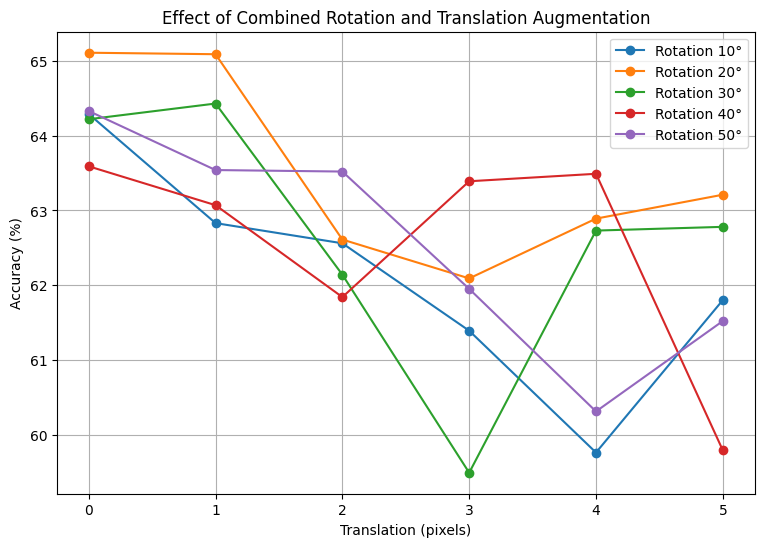

In [35]:
plt.figure(figsize=(9, 6))

for angle in rotation_constraints:

    accuracies_for_angle = []

    for shift in translation_constraints:

        for result_angle, result_shift, acc in combined_results:

            if result_angle == angle and result_shift == shift:
                accuracies_for_angle.append(acc * 100)
                break

    plt.plot(
        translation_constraints,
        accuracies_for_angle,
        marker="o",
        label=f"Rotation {angle}°"
    )

plt.xlabel("Translation (pixels)")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Combined Rotation and Translation Augmentation")

plt.legend()
plt.grid()
plt.show()

In [34]:
best_combination = max(
    combined_results,
    key=lambda x: x[2]
)

print(
    "Best rotation:",
    best_combination[0],
    "degrees"
)

print(
    "Best translation:",
    best_combination[1],
    "pixels"
)

print(
    "Best accuracy:",
    best_combination[2] * 100,
    "%"
)

print(
    "Baseline accuracy: 64.72 %"
)

print(
    "Improvement:",
    (best_combination[2] - 0.6472) * 100,
    "percentage points"
)

Best rotation: 20 degrees
Best translation: 0 pixels
Best accuracy: 65.11 %
Baseline accuracy: 64.72 %
Improvement: 0.39000000000000146 percentage points


The effect of combining rotation and translation augmentation was evaluated using different combinations of rotation angles and translation values.

The best result obtained was:

Rotation: 20°  
Translation: 0 pixels  
Accuracy: 65.11%  
Baseline accuracy: 64.72%  
Improvement: 0.39 percentage points  

Since the best combination used 0-pixel translation, adding translation did not provide an additional benefit in this experiment. Also, the best combined result of 65.11% was lower than the 68.47% obtained with rotation alone in Q1.

Conclusion: Combining rotation and translation did not improve the classifier compared with rotation alone. The best observed combined result was 65.11%, while rotation alone achieved 68.47%.

Answer 5.

In [36]:
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(train_X_full, train_y_full), (test_X, test_y) = mnist.load_data()

train_X_full = train_X_full / 255.0
test_X = test_X / 255.0

print("Full training set:", train_X_full.shape)
print("Test set:", test_X.shape)

Full training set: (60000, 28, 28)
Test set: (10000, 28, 28)


In [37]:
def create_balanced_dataset(images_per_digit):

    selected_X = []
    selected_y = []

    for digit in range(10):

        indices = np.where(train_y_full == digit)[0]

        selected_indices = indices[:images_per_digit]

        selected_X.append(
            train_X_full[selected_indices]
        )

        selected_y.append(
            train_y_full[selected_indices]
        )

    selected_X = np.concatenate(selected_X)
    selected_y = np.concatenate(selected_y)

    return selected_X, selected_y

In [38]:
images_per_digit_list = [1, 2, 5, 10, 20, 30, 40, 50]

q5_baseline_accuracies = []

for n in images_per_digit_list:

    small_X, small_y = create_balanced_dataset(n)

    testpred = NN(
        small_X,
        small_y,
        test_X
    )

    acc = Accuracy(
        test_y,
        testpred
    )

    q5_baseline_accuracies.append(acc)

    print(
        "Images per digit:",
        n,
        "| Total training samples:",
        len(small_X),
        "| Accuracy:",
        acc * 100,
        "%"
    )

Images per digit: 1 | Total training samples: 10 | Accuracy: 50.99 %
Images per digit: 2 | Total training samples: 20 | Accuracy: 56.42 %
Images per digit: 5 | Total training samples: 50 | Accuracy: 65.47 %
Images per digit: 10 | Total training samples: 100 | Accuracy: 69.28999999999999 %
Images per digit: 20 | Total training samples: 200 | Accuracy: 76.34 %
Images per digit: 30 | Total training samples: 300 | Accuracy: 80.67 %
Images per digit: 40 | Total training samples: 400 | Accuracy: 81.83 %
Images per digit: 50 | Total training samples: 500 | Accuracy: 83.54 %


In [39]:
q5_aug_accuracies = []

angleconstraint = 30
naugmentations = 5

for n in images_per_digit_list:

    small_X, small_y = create_balanced_dataset(n)

    augdata = small_X
    auglabel = small_y

    for jj in range(naugmentations):

        augmented = augRotate(
            small_X,
            angleconstraint
        )

        augdata = np.concatenate(
            (
                augdata,
                augmented
            )
        )

        auglabel = np.concatenate(
            (
                auglabel,
                small_y
            )
        )

    testpred = NN(
        augdata,
        auglabel,
        test_X
    )

    acc = Accuracy(
        test_y,
        testpred
    )

    q5_aug_accuracies.append(acc)

    print(
        "Images per digit:",
        n,
        "| Original samples:",
        len(small_X),
        "| Augmented samples:",
        len(augdata),
        "| Accuracy:",
        acc * 100,
        "%"
    )

Images per digit: 1 | Original samples: 10 | Augmented samples: 60 | Accuracy: 54.910000000000004 %
Images per digit: 2 | Original samples: 20 | Augmented samples: 120 | Accuracy: 64.13 %
Images per digit: 5 | Original samples: 50 | Augmented samples: 300 | Accuracy: 70.71 %
Images per digit: 10 | Original samples: 100 | Augmented samples: 600 | Accuracy: 74.75 %
Images per digit: 20 | Original samples: 200 | Augmented samples: 1200 | Accuracy: 80.81 %
Images per digit: 30 | Original samples: 300 | Augmented samples: 1800 | Accuracy: 85.05 %
Images per digit: 40 | Original samples: 400 | Augmented samples: 2400 | Accuracy: 86.18 %
Images per digit: 50 | Original samples: 500 | Augmented samples: 3000 | Accuracy: 87.35000000000001 %


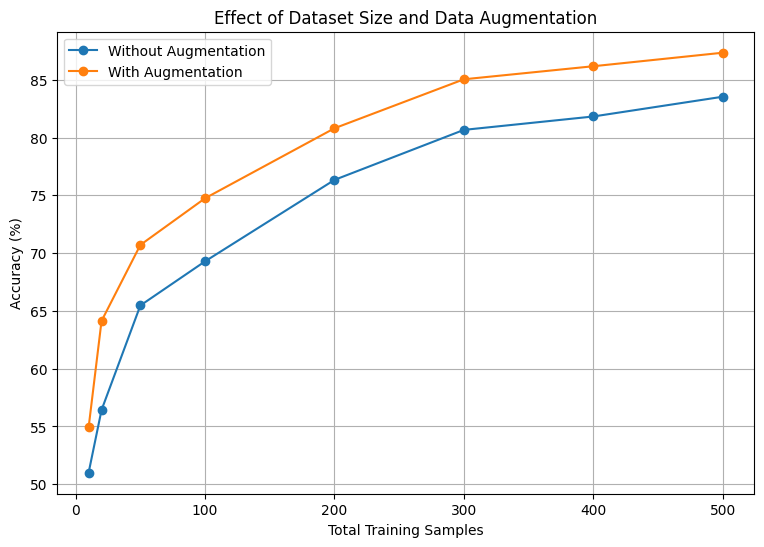

In [41]:
# Baseline results from the previous experiment
q5_accuracies = [
    0.5099,  # 1 image per digit
    0.5642,  # 2
    0.6547,  # 5
    0.6929,  # 10
    0.7634,  # 20
    0.8067,  # 30
    0.8183,  # 40
    0.8354   # 50
]

# Augmented results from your latest experiment
q5_aug_accuracies = [
    0.5491,  # 1 image per digit
    0.6413,  # 2
    0.7071,  # 5
    0.7475,  # 10
    0.8081,  # 20
    0.8505,  # 30
    0.8618,  # 40
    0.8735   # 50
]

total_samples = [n * 10 for n in images_per_digit_list]

plt.figure(figsize=(9, 6))

plt.plot(
    total_samples,
    [acc * 100 for acc in q5_accuracies],
    marker="o",
    label="Without Augmentation"
)

plt.plot(
    total_samples,
    [acc * 100 for acc in q5_aug_accuracies],
    marker="o",
    label="With Augmentation"
)

plt.xlabel("Total Training Samples")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Dataset Size and Data Augmentation")
plt.legend()
plt.grid()
plt.show()

In [42]:
print("WITHOUT AUGMENTATION")

for i, n in enumerate(images_per_digit_list):
    if q5_accuracies[i] > 0.50:
        print("Smallest dataset:", n, "image per digit")
        print("Total samples:", n * 10)
        print("Accuracy:", q5_accuracies[i] * 100, "%")
        break


print("\nWITH AUGMENTATION")

for i, n in enumerate(images_per_digit_list):
    if q5_aug_accuracies[i] > 0.50:
        print("Smallest original dataset:", n, "image per digit")
        print("Original samples:", n * 10)
        print("Augmented samples:", n * 10 * 6)
        print("Accuracy:", q5_aug_accuracies[i] * 100, "%")
        break

WITHOUT AUGMENTATION
Smallest dataset: 1 image per digit
Total samples: 10
Accuracy: 50.99 %

WITH AUGMENTATION
Smallest original dataset: 1 image per digit
Original samples: 10
Augmented samples: 60
Accuracy: 54.910000000000004 %


The experiment was performed using a balanced MNIST dataset, with the same number of images selected for each digit.

Without data augmentation, the smallest tested dataset that achieved more than 50% accuracy was 1 image per digit, giving a total of 10 training images. It achieved an accuracy of 50.99%.

With rotation-based data augmentation using a 30° rotation constraint and 5 augmented copies, the same dataset of 10 original images was expanded to 60 training samples. The accuracy increased to 54.91%.

| Images per digit | Total original samples | Without Augmentation | With Augmentation |
|---:|---:|---:|---:|
| 1 | 10 | 50.99% | 54.91% |
| 2 | 20 | 56.42% | 64.13% |
| 5 | 50 | 65.47% | 70.71% |
| 10 | 100 | 69.29% | 74.75% |
| 20 | 200 | 76.34% | 80.81% |
| 30 | 300 | 80.67% | 85.05% |
| 40 | 400 | 81.83% | 86.18% |
| 50 | 500 | 83.54% | 87.35% |

The results show that accuracy generally increases as the number of training samples increases. Data augmentation also improves accuracy for every dataset size tested. For the smallest dataset, augmentation improved accuracy from 50.99% to 54.91%, an improvement of 3.92 percentage points.

Therefore, the smallest tested dataset achieving more than 50% accuracy is 10 original images (1 image per digit). With augmentation, these 10 images produced 60 training samples and achieved 54.91% accuracy.